In [17]:
import numpy as np
import pandas as pd
import math
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"font.size": 16})       

In [18]:
df = pd.read_csv('new_math_df.csv')

In [19]:
df.columns

Index(['tutor', 'conversation_id', 'student_mistake', 'tutors_response',
       'PressReasoning_prob', 'PressAccuracy_prob', 'Uptake_prob',
       'politeness_score', 'agency_score', 'flesch_reading_ease', 'mtld',
       'word_count', 'flesch_score', 'flesch_ease', 'Mistake_Identification',
       'Mistake_Location', 'Actionability', 'Providing_Guidance'],
      dtype='object')

In [20]:
df['pedagogy_score'] = df.Mistake_Identification + df.Mistake_Location + df.Actionability + df.Providing_Guidance

In [21]:
mtld_na = df[df.mtld.isna()].conversation_id.tolist()

In [22]:
df = df[~df.conversation_id.isin(mtld_na)]

In [23]:
df["mtld_log"] = np.log1p(df["mtld"])
df["word_count_log"] = np.log1p(df["word_count"])

In [24]:
df.tutor.unique()

array(['Sonnet', 'Llama318B', 'Llama31405B', 'GPT4', 'Mistral', 'Expert',
       'Gemini', 'Phi3', 'Novice'], dtype=object)

In [25]:
features = [
    "PressReasoning_prob",
    "PressAccuracy_prob",
    "Uptake_prob",
    "word_count_log",
    "mtld_log",
    "flesch_reading_ease",
    "politeness_score",
    "agency_score",
]

feature_labels = {
    "PressReasoning_prob": "Pressing for reasoning",
    "PressAccuracy_prob": "Pressing for accuracy",
     "Uptake_prob": "Restating/Revoicing",
    "word_count_log": "Response length (log transformed)",
    "mtld_log": "Lexical diversity (MTLD)",
    "flesch_reading_ease": "Readability",
    "politeness_score": "Politeness",
    "agency_score": "Agency",
}

In [26]:
expert_tutor = "Expert"   # set to your exact label
novice_tutor = "Novice"   # set to your exact label

# Optional: order tutors with humans first, then LLMs alphabetical
tutors = list(df["tutor"].unique())
llms = sorted([t for t in tutors if t not in {expert_tutor, novice_tutor}])
tutor_order = [expert_tutor, novice_tutor] + llms

# If your labels differ or expert/novice are missing from the data, filter safely:
tutor_order = [t for t in tutor_order if t in tutors]

def paired_diff_stats(x, y):
    d = (x - y).dropna()
    n = len(d)
    mean = d.mean()
    se = d.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    ci = 1.96 * se
    return mean, ci, n

wide = {}
for f in features:
    wide[f] = df.pivot_table(
        index="conversation_id",
        columns="tutor",
        values=f,
        aggfunc="mean"
    )

rows = []
for f in features:
    for llm in llms:
        if llm not in wide[f].columns:
            continue
        m, ci, n = paired_diff_stats(wide[f][llm], wide[f]['Expert'])
        rows.append({
            "feature": f,
            "llm": llm,
            "mean_diff": m,
            "ci": ci,
            "n_turns": n
        })

diff_df = pd.DataFrame(rows)
novice = "Novice"        # your exact label
expert = "Expert"        # your exact label
NOV_LABEL = "Novice (ref)"

rows_nov = []
for f in features:
    w = wide[f]
    if novice not in w.columns or expert not in w.columns:
        continue

    # Overlap subset: turns where BOTH novice and expert have values
    mask = w[novice].notna() & w[expert].notna()
    if mask.sum() < 5:   # you can set a threshold (e.g., 10) if you prefer
        continue

    m, ci, n = paired_diff_stats(w.loc[mask, novice], w.loc[mask, expert])
    rows_nov.append({
        "feature": f,
        "llm": NOV_LABEL,     # reuse the plotting column
        "mean_diff": m,
        "ci": ci,
        "n_turns": n,
        "is_novice_ref": True
    })

nov_df = pd.DataFrame(rows_nov)

# Ensure your existing diff_df has this flag too
diff_df = diff_df.copy()
diff_df["is_novice_ref"] = False

diff_df2 = pd.concat([diff_df, nov_df], ignore_index=True)

# Figure 1

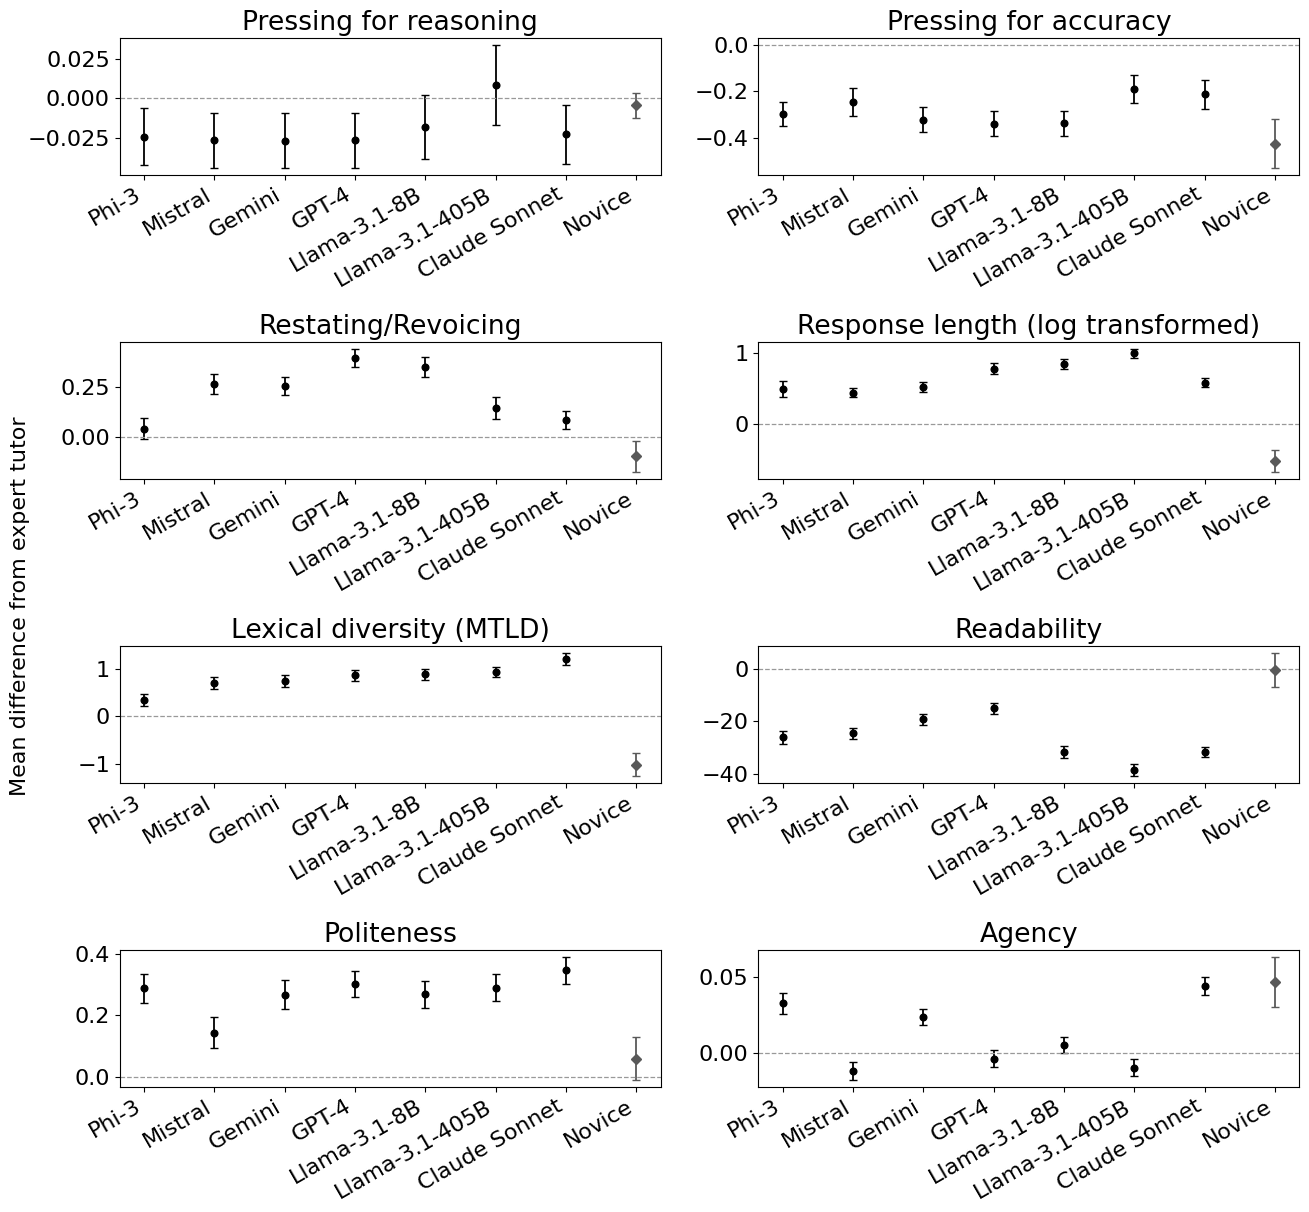

In [27]:
n_feats = len(features)
ncols = 2
nrows = math.ceil(n_feats / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(13.2, 3.1 * nrows), sharex=False)
axes = np.array(axes).reshape(nrows, ncols)

# name mapping
name_map = {
    "GPT4": "GPT-4",
    "Gemini": "Gemini",
    "Mistral": "Mistral",
    "Phi3": "Phi-3",
    "Sonnet": "Claude Sonnet",
    "Llama31405B": "Llama-3.1-405B",
    "Llama318B": "Llama-3.1-8B",
    "Novice (ref)": "Novice",
}

# tutor order
model_order = [
    "Phi3", "Mistral", "Gemini", "GPT4", "Llama318B", "Llama31405B", "Sonnet", "Novice"
]

# Helper for ordering
def order_key(x):
    try:
        return model_order.index(x)
    except ValueError:
        return 999

for i, f in enumerate(features):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    sub = diff_df2[diff_df2["feature"] == f].copy()

    # Ensure we have novice row flagged correctly; keep novice last
    sub["order"] = sub["llm"].apply(order_key)
    sub = sub.sort_values("order")

    # Map display names
    sub["label"] = sub["llm"].map(name_map).fillna(sub["llm"])

    # X positions
    x = np.arange(len(sub))
    y = sub["mean_diff"].to_numpy()
    yerr = sub["ci"].to_numpy()
    is_nov = sub["is_novice_ref"].to_numpy()

    # LLMs: neutral markers (single color)
    ax.errorbar(
        x[~is_nov], y[~is_nov], yerr=yerr[~is_nov],
        fmt="o", capsize=3.2, elinewidth=1.3, markersize=4.8, color="black"
    )

    # Novice reference: gray diamond (no “special color” beyond gray)
    if is_nov.any():
        ax.errorbar(
            x[is_nov], y[is_nov], yerr=yerr[is_nov],
            fmt="D", capsize=3.2, elinewidth=1.3, markersize=5.2,
            color="0.35"
        )

    # Lighter zero line (since repeated in every panel)
    ax.axhline(0, linestyle="--", color="0.6", linewidth=0.9)

    # Titles: keep short
    ax.set_title(f"{feature_labels[f]}")#(Tutor − Expert)

    # X ticks: set labels, but show only on bottom row to reduce clutter
    ax.set_xticks(x)
    ax.set_xticklabels(sub["label"].tolist(), rotation=30, ha="right")

    # Determine last occupied row for each column
    last_row_per_col = {}
    for idx in range(n_feats):
        rr, cc = divmod(idx, ncols)
        last_row_per_col[cc] = max(last_row_per_col.get(cc, -1), rr)
    
    # Hide x labels except for the last occupied row in each column
    # if r != last_row_per_col[c]:
    #     ax.set_xticklabels([])


    # Remove per-axis y label; will add one global label
    ax.set_ylabel("")

    # Lighten frame
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

# Hide unused panels
for j in range(n_feats, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis("off")

# Global y-label and title
fig.text(0.005, 0.5, "Mean difference from expert tutor", va="center", rotation="vertical")
# fig.suptitle("Instructional and linguistic profiles relative to expert (raw-scale differences)", y=1.01, fontsize=14)

fig.tight_layout()
plt.savefig('plots/feature_plot_realtivetoexpert.pdf', dpi=300, bbox_inches="tight")
plt.show()

# Figure 2

In [28]:
y_col = "pedagogy_score"
id_col = "conversation_id"
tutor_col = "tutor"
d = df[[id_col, y_col, tutor_col] + features].dropna().copy()
d["pedagogy_within"] = d[y_col] - d.groupby(id_col)[y_col].transform("mean")

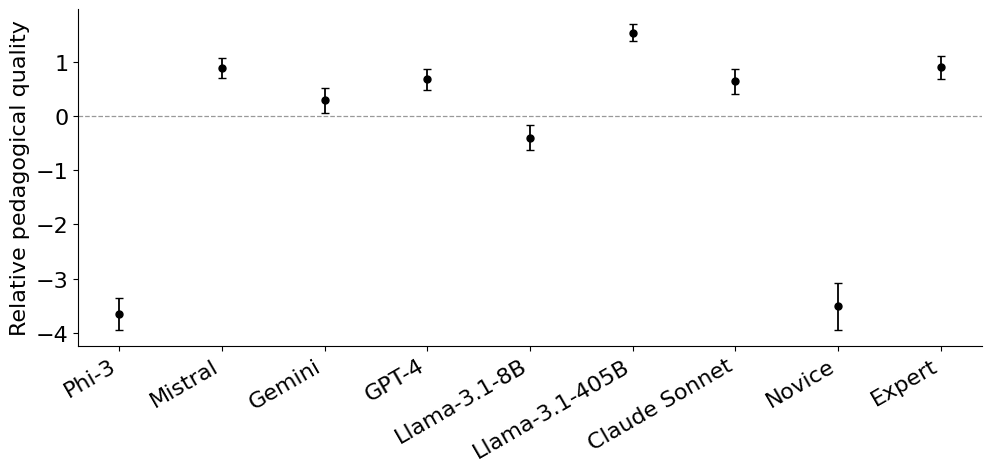

In [29]:
def se_mean(x):
    n = len(x)
    if n <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(n)

stats = (
    d.groupby(tutor_col)["pedagogy_within"]
     .agg(mean="mean", se=se_mean, n="size")
     .reset_index()
)
model_order = [
    "Phi3", "Mistral", "Gemini", "GPT4", "Llama318B", "Llama31405B", "Sonnet", "Novice"
]
tutor_order = model_order + ['Expert']
# enforce consistent order
stats["order"] = stats[tutor_col].apply(lambda t: tutor_order.index(t) if t in tutor_order else 999)
stats = stats.sort_values("order")

# display labels
stats["label"] = stats[tutor_col].map(name_map).fillna(stats[tutor_col])

x = np.arange(len(stats))

fig, ax = plt.subplots(figsize=(10.2, 5))
ax.errorbar(
    x, stats["mean"],
    yerr=1.96 * stats["se"],
    fmt="o",
    capsize=3.2,
    elinewidth=1.3,
    markersize=5,
    color="black"
)

# zero line (meaningful reference)
ax.axhline(0, color="0.6", linestyle="--", linewidth=0.9)

ax.set_xticks(x)
ax.set_xticklabels(stats["label"], rotation=30, ha="right")
ax.set_ylabel("Relative pedagogical quality")
 # explain in caption
# ax.set_title("Perceived pedagogical quality relative to the conversation-turn average")

# cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("plots/relative_pedagogical_quality.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3

In [30]:
# 1. Within-error-turn demeaning
within = d.groupby(id_col)[[y_col] + features].transform("mean")
d_w = d[[y_col] + features] - within

# 2. Z-score predictors AFTER demeaning
X = d_w[features]
X = (X - X.mean()) / X.std()

y = d_w[y_col]

X_const = sm.add_constant(X)
m_const = sm.OLS(y, X_const).fit(
    cov_type="cluster",
    cov_kwds={"groups": d[id_col]}
)
with open("regression_table.tex", "w") as f:
    f.write(m_const.summary().as_latex())
print(m_const.summary())

                            OLS Regression Results                            
Dep. Variable:         pedagogy_score   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     110.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.19e-84
Time:                        05:44:38   Log-Likelihood:                -5387.4
No. Observations:                2444   AIC:                         1.079e+04
Df Residuals:                    2435   BIC:                         1.085e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                4.337e-18   3

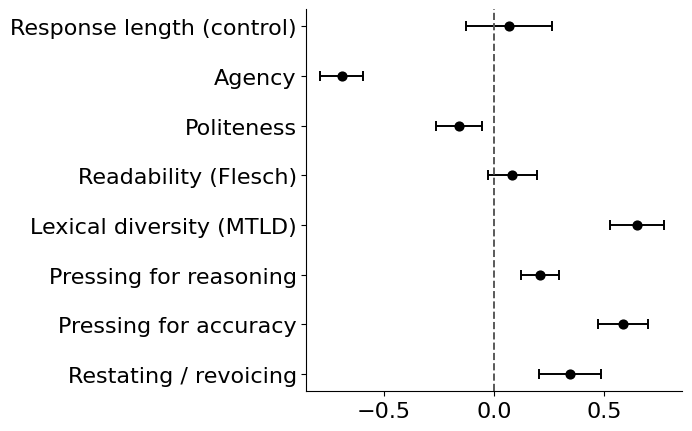

In [31]:
# Extract results
res = m_const  # OLS model with clustered SEs (by conversation turn)
coefs = res.params
ses = res.bse

coef_df = pd.DataFrame({
    "feature": coefs.index.astype(str),
    "coef": coefs.values,
    "se": ses.values
})

# Drop intercept/constant (common names across statsmodels specs)
drop_terms = {"const", "Intercept", "(Intercept)"}
coef_df = coef_df[~coef_df["feature"].isin(drop_terms)].copy()

# Compute 95% CI
z = 1.96
coef_df["ci_low"] = coef_df["coef"] - z * coef_df["se"]
coef_df["ci_high"] = coef_df["coef"] + z * coef_df["se"]

# map labels
label_map = {
    "Uptake_prob": "Restating / revoicing",
    "PressAccuracy_prob": "Pressing for accuracy",
    "PressReasoning_prob":"Pressing for reasoning",
    "mtld_log": "Lexical diversity (MTLD)",
    "flesch_reading_ease": "Readability (Flesch)",
    "politeness_score": "Politeness",
    "agency_score": "Agency",
    "word_count_log": "Response length (control)",    
}

coef_df["label"] = coef_df["feature"].map(label_map).fillna(coef_df["feature"])

# Conceptual ordering (instructional-linguistic-control)
desired_order = [
    "Restating / revoicing",
    "Pressing for accuracy",
    "Pressing for reasoning",
    "Lexical diversity (MTLD)",
    "Readability (Flesch)",
    "Politeness",
    "Agency",
    "Response length (control)",
]

# Keep labels in desired order
present = [x for x in desired_order if x in set(coef_df["label"])]
# Append other features if any
extras = [x for x in coef_df["label"].unique() if x not in present]
final_order = present + sorted(extras)

coef_df["label"] = pd.Categorical(coef_df["label"], categories=final_order, ordered=True)
coef_df = coef_df.sort_values("label")

# Plot
fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.errorbar(
    coef_df["coef"],
    coef_df["label"],
    xerr=z * coef_df["se"],
    fmt="o",
    markersize=5.5,
    elinewidth=1.4,
    capsize=3.5,
    capthick=1.4,
    color="black"  
)

# draw markers
ax.scatter(coef_df["coef"], coef_df["label"], c='black', s=40, zorder=3)

# Zero reference line
ax.axvline(0, color="0.35", linestyle="--", linewidth=1.4)

# symmetric x-limits for easier visual comparison
max_abs = np.max(np.abs(np.r_[coef_df["ci_low"].values, coef_df["ci_high"].values]))
pad = 0.08 * max_abs
ax.set_xlim(-(max_abs + pad), (max_abs + pad))

ax.set_xlabel("")
ax.set_ylabel("")
#ax.set_title("Instructional and linguistic features associated with perceived pedagogical quality")

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("plots/coef_plot_pedagogical_quality.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Difference across subgroups based on mistake identification/pedagogy score

In [32]:
df.groupby(df.Mistake_Identification > 0)['agency_score'].mean()

Mistake_Identification
False    0.552042
True     0.517442
Name: agency_score, dtype: float64

In [33]:
df.groupby(df.Mistake_Identification > 0)['politeness_score'].mean()

Mistake_Identification
False    0.881045
True     0.822259
Name: politeness_score, dtype: float64

In [34]:
high = df[df.pedagogy_score >= 3]
low  = df[df.pedagogy_score <= 1]

In [35]:
high['agency_score'].mean(), low['agency_score'].mean()

(np.float64(0.5157694297276362), np.float64(0.560554272990625))

In [36]:
high['politeness_score'].mean(), low['politeness_score'].mean()

(np.float64(0.8191815471824088), np.float64(0.896435016153125))

In [37]:
from scipy.stats import ttest_ind

identified = df[df.pedagogy_score > 1]['agency_score']
not_identified = df[df.pedagogy_score < 1]['agency_score']

ttest_ind(not_identified, identified, equal_var=False)

TtestResult(statistic=np.float64(16.540331424769203), pvalue=np.float64(4.773956999971099e-43), df=np.float64(272.98804657564415))

In [38]:
from scipy.stats import mannwhitneyu

mannwhitneyu(not_identified, identified, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(385088.5), pvalue=np.float64(8.299402213027897e-48))

In [39]:
identified.median(), not_identified.median()

(np.float64(0.512908876), np.float64(0.577323258))